# China Automotive Market Analysis: Sales Forecasting, Product Specifications, and User Needs

This notebook reproduces the main results and figures from saved analysis artifacts. Collection, labeling, and model-fitting scripts are in `scripts/`.

**Study period:** 2022-01—2026-07

**Forecast test:** 2026-01—06
**Primary metric:** global volume-weighted WMAPE


In [1]:
ZH = False
%matplotlib inline
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"
FORECAST_DIR = DATA / "processed" / "forecast"
PRODUCT_DIR = DATA / "processed" / "product"
FEEDBACK_DIR = DATA / "processed" / "user_feedback"
REVIEW_DIR = DATA / "reviews" / "processed"

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 120,
    "font.family": "sans-serif",
    "font.sans-serif": ["PingFang SC", "Hiragino Sans GB", "Noto Sans CJK SC",
                        "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#dfe4e8", "grid.linewidth": 0.7,
    "axes.facecolor": "#fbfbfa", "figure.facecolor": "white",
})
COLORS = {"navy": "#162334", "blue": "#316fbd", "light": "#9bb9dd",
          "orange": "#d9902f", "red": "#c75357", "gray": "#8b98a7"}

def read_json(path):
    with open(path, "r", encoding="utf-8-sig") as handle:
        return json.load(handle)

print("Project root:", ROOT)


Project root: /Users/ye/dev/projects/china-auto-market-analysis


In [2]:
sales = pd.read_csv(DATA / "raw" / "monthly_sales.csv")
specs = pd.read_csv(DATA / "raw" / "feature.csv")
train = pd.read_csv(DATA / "processed" / "splits" / "train.csv")
val = pd.read_csv(DATA / "processed" / "splits" / "val.csv")
test = pd.read_csv(DATA / "processed" / "splits" / "test.csv")
split_manifest = read_json(DATA / "processed" / "splits" / "manifest.json")
corpus = read_json(REVIEW_DIR / "target_371_review_corpus_summary.json")
labels = read_json(REVIEW_DIR / "review_aspect_labels_summary.json")
temporal = read_json(REVIEW_DIR / "review_feature_temporal_summary.json")
forecast = pd.read_csv(FORECAST_DIR / "review_feature_ablation_summary.csv", encoding="utf-8-sig")
robustness = read_json(FORECAST_DIR / "forecast_robustness_summary.json")
cold = read_json(FORECAST_DIR / "cold_start_launch_curve_summary.json")
config = pd.read_csv(PRODUCT_DIR / "config_attribution_ablation.csv")
aspects = pd.read_csv(FEEDBACK_DIR / "user_need_aspect_summary.csv", encoding="utf-8-sig")
alerts = pd.read_csv(FEEDBACK_DIR / "sentiment_alerts.csv")
monitor = read_json(FEEDBACK_DIR / "user_needs_alerts_summary.json")
print("Loaded analysis artifacts.")


Loaded analysis artifacts.


## 1. Three analysis samples

Forecasting requires continuous monthly history; the specification analysis requires aligned annual sales and product attributes; the user-needs analysis requires complete and traceable review text.


In [3]:
if ZH:
    table = pd.DataFrame([
        ["六个月销量预测", "371 个车系", "2,226 条测试车系月", "固定起点递归预测"],
        ["产品配置分析", "736 个车系", "2,007 条车系年记录", "GroupKFold(5) 按车系"],
        ["用户需求与风险", "345 个车系", "24,175 条评论", "质量审计 + 180 天窗口"],
    ], columns=["分析", "样本", "观测", "验证"])
    source = pd.DataFrame([
        ["月销量", f"{sales.series_name.nunique():,} 个车系 / {len(sales):,} 行"],
        ["车型配置", f"{specs.series_name.nunique():,} 个车系 / {len(specs):,} 行"],
        ["严格评论语料", f"{corpus['temporally_eligible_reviews']:,} 条 / "
                         f"{corpus['target_series_with_any_review']} 个车系"],
    ], columns=["数据底座", "规模"])
else:
    table = pd.DataFrame([
        ["Six-month sales forecast", "371 series", "2,226 test series-months",
         "Fixed-origin recursive forecast"],
        ["Product specifications", "736 series", "2,007 series-year records",
         "Five-fold GroupKFold by series"],
        ["User needs and risk", "345 series", "24,175 reviews",
         "Quality audit + 180-day windows"],
    ], columns=["Analysis", "Sample", "Observations", "Validation"])
    source = pd.DataFrame([
        ["Monthly sales", f"{sales.series_name.nunique():,} series / {len(sales):,} rows"],
        ["Vehicle specifications", f"{specs.series_name.nunique():,} series / {len(specs):,} rows"],
        ["Strict review corpus", f"{corpus['temporally_eligible_reviews']:,} reviews / "
                                 f"{corpus['target_series_with_any_review']} series"],
    ], columns=["Data foundation", "Scale"])
display(table)
display(source)


,Analysis,Sample,Observations,Validation
0,Six-month sales forecast,371 series,"2,226 test series-months",Fixed-origin recursive forecast
1,Product specifications,736 series,"2,007 series-year records",Five-fold GroupKFold by series
2,User needs and risk,345 series,"24,175 reviews",Quality audit + 180-day windows


,Data foundation,Scale
0,Monthly sales,"1,017 series / 54,918 rows"
1,Vehicle specifications,"766 series / 2,084 rows"
2,Strict review corpus,"24,175 reviews / 345 series"


## 2. Monthly sales forecasting

Training ends in 2025-06, validation covers 2025-07—12, and testing covers 2026-01—06. The test uses a January 2026 fixed origin; review features are frozen at the same origin.


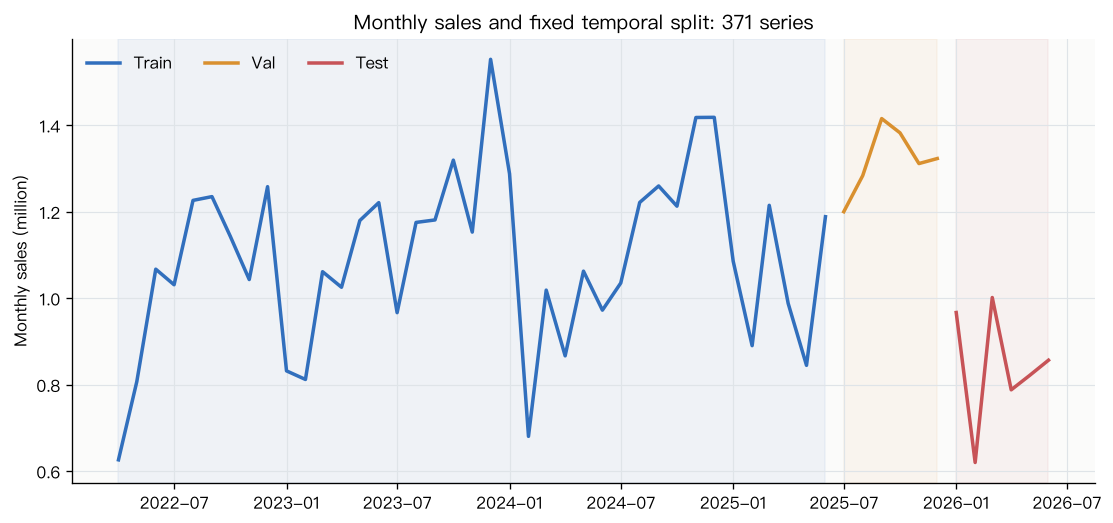

In [4]:
panel = pd.concat([
    train[["date", "monthly_sales", "split"]],
    val[["date", "monthly_sales", "split"]],
    test[["date", "monthly_sales", "split"]],
], ignore_index=True)
panel["date"] = pd.to_datetime(panel["date"])
monthly = panel.groupby(["date", "split"], as_index=False)["monthly_sales"].sum()
fig, ax = plt.subplots(figsize=(11, 4.8))
for split, color in [("train", COLORS["blue"]), ("val", COLORS["orange"]), ("test", COLORS["red"])]:
    part = monthly[monthly["split"] == split]
    ax.plot(part["date"], part["monthly_sales"] / 1e6, color=color, lw=2.1, label=split.title())
    ax.axvspan(part["date"].min(), part["date"].max(), color=color, alpha=0.06)
ax.set(title=("371 车系月销量与固定时间切分" if ZH else
              "Monthly sales and fixed temporal split: 371 series"),
       xlabel="", ylabel=("月销量（百万辆）" if ZH else "Monthly sales (million)"))
ax.legend(frameon=False, ncol=3)
plt.show()


### Model comparison

Global WMAPE is followed by median per-series WMAPE for the long tail. The two metrics have different denominators and aggregation rules and should not be substituted for each other.


,Model,Global WMAPE,Median per-series WMAPE
1,Sales baseline,40.44%,49.98%
4,Owner-feedback enhanced,38.71%,48.83%
2,Cold-start supplement,38.64%,48.32%


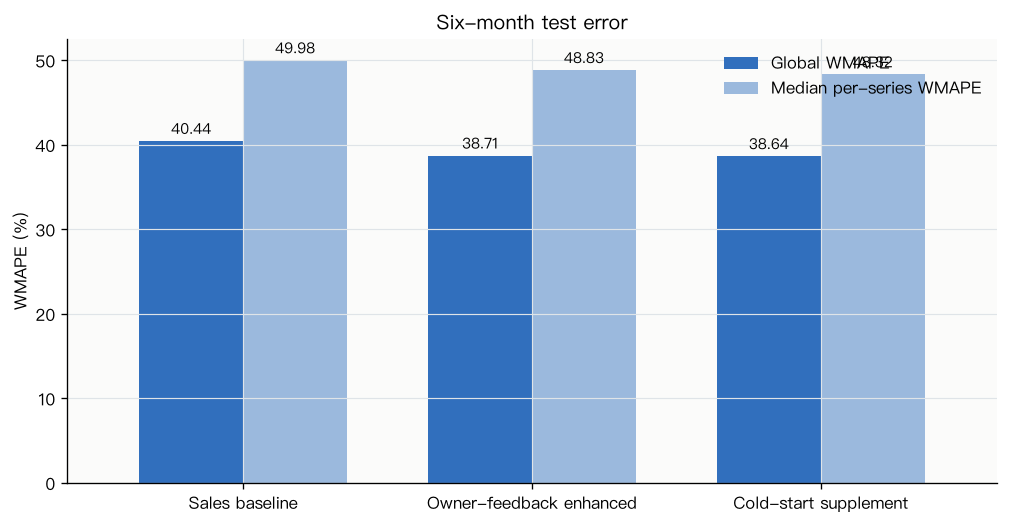

In [5]:
model_name = "方案" if ZH else "Model"
global_name = "全局 WMAPE" if ZH else "Global WMAPE"
median_name = "逐车系中位数 WMAPE" if ZH else "Median per-series WMAPE"
names = {
    "BASE": "销量基线" if ZH else "Sales baseline",
    "REVIEW_RICH_FIXED": "用户口碑增强" if ZH else "Owner-feedback enhanced",
}
main = forecast[forecast.version.isin(names)].copy()
main[model_name] = main.version.map(names)
main = main[[model_name, "global_volume_weighted_WMAPE", "median_per_series_WMAPE"]]
main.columns = [model_name, global_name, median_name]
main.loc[len(main)] = [
    "冷启动补充" if ZH else "Cold-start supplement",
    cold["hybrid_full371_global_WMAPE"],
    cold["hybrid_full371_median_per_series_WMAPE"],
]
display(main.style.format({global_name: "{:.2f}%", median_name: "{:.2f}%"}))
ax = main.set_index(model_name).plot.bar(
    color=[COLORS["blue"], COLORS["light"]], width=0.72, figsize=(10, 4.8))
ax.set(title=("六个月测试集误差" if ZH else "Six-month test error"),
       xlabel="", ylabel="WMAPE (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
plt.show()


### Improvement and uncertainty

The owner-feedback model lowers global WMAPE by 1.73 percentage points. The series-cluster bootstrap interval still crosses zero, supporting a modest improvement signal rather than a stable proven advantage.


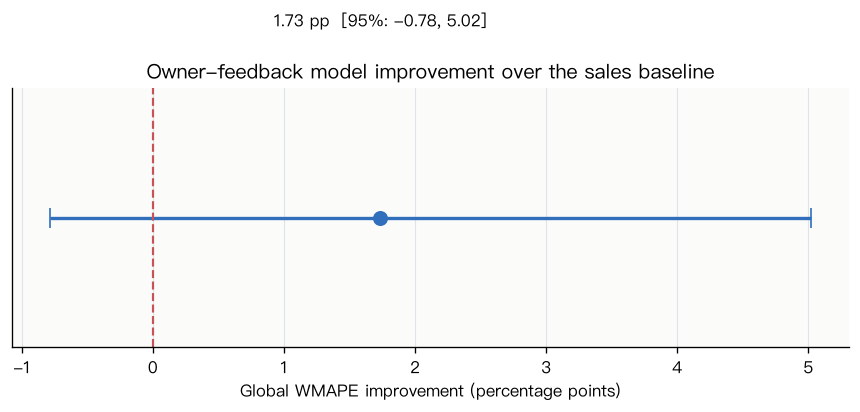

Share of bootstrap replicates better than baseline: 89.8%
Test months better than baseline: 5 / 6


In [6]:
point = robustness["review_rich_vs_base_improvement_pp"]
low, high = robustness["review_rich_vs_base_bootstrap_95pct_ci_pp"]
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.errorbar(point, 0, xerr=np.array([[point-low], [high-point]]),
            fmt="o", markersize=8, color=COLORS["blue"], capsize=6, lw=2)
ax.axvline(0, color=COLORS["red"], ls="--", lw=1.3)
ax.set(title=("用户口碑增强模型相对销量基线的改善" if ZH else
              "Owner-feedback model improvement over the sales baseline"),
       xlabel=("全局 WMAPE 改善（百分点）" if ZH else
               "Global WMAPE improvement (percentage points)"), yticks=[])
ax.text(point, .08, f"{point:.2f} pp  [95%: {low:.2f}, {high:.2f}]",
        ha="center", va="bottom")
plt.show()
if ZH:
    print(f"重采样中优于基线的比例：{robustness['review_rich_vs_base_probability_better']:.1%}")
    print(f"六个测试月中优于基线：{robustness['test_months_review_rich_better_than_base']} / 6")
else:
    print("Share of bootstrap replicates better than baseline: "
          f"{robustness['review_rich_vs_base_probability_better']:.1%}")
    print(f"Test months better than baseline: {robustness['test_months_review_rich_better_than_base']} / 6")


### Information contribution


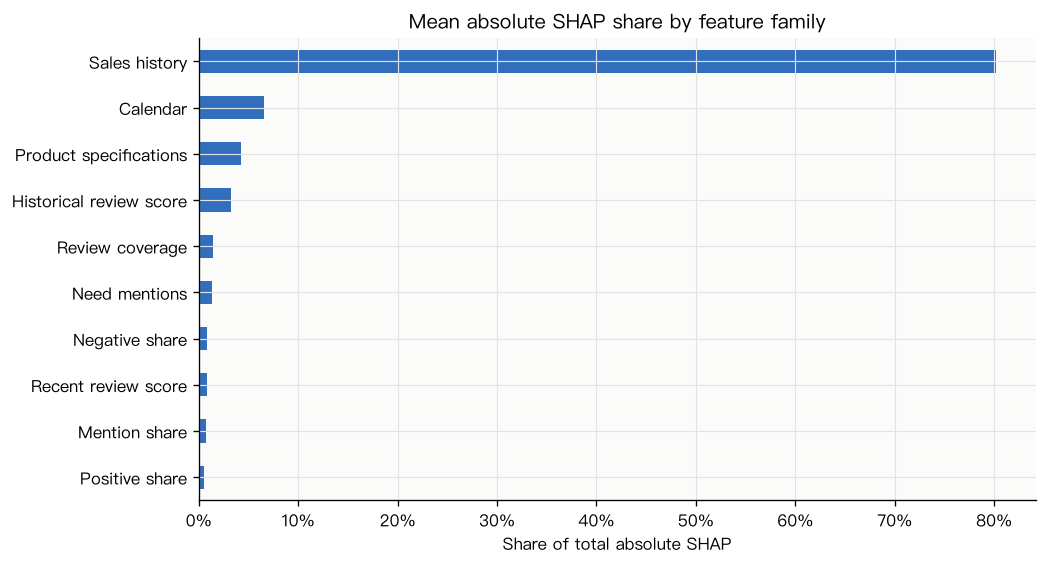

In [7]:
family = pd.read_csv(FORECAST_DIR / "review_feature_family_importance.csv",
                     encoding="utf-8-sig")
maps = {
    "zh": {"sales_lag_roll": "历史销量", "calendar": "日历", "configuration": "产品配置",
           "review_expanding_score": "历史评价得分", "review_observation_context": "评论覆盖",
           "review_mention_count": "需求提及量", "review_negative_rate": "负面比例",
           "review_recent_score": "近期评价得分", "review_mention_rate": "需求提及率",
           "review_positive_rate": "正面比例"},
    "en": {"sales_lag_roll": "Sales history", "calendar": "Calendar",
           "configuration": "Product specifications",
           "review_expanding_score": "Historical review score",
           "review_observation_context": "Review coverage",
           "review_mention_count": "Need mentions", "review_negative_rate": "Negative share",
           "review_recent_score": "Recent review score",
           "review_mention_rate": "Mention share", "review_positive_rate": "Positive share"},
}
label = "信息类型" if ZH else "Information"
family[label] = family.feature_family.map(maps["zh" if ZH else "en"])
family = family.dropna(subset=[label]).sort_values("share_of_total_abs_shap")
ax = family.plot.barh(x=label, y="share_of_total_abs_shap", color=COLORS["blue"],
                      legend=False, figsize=(9, 5))
ax.set(title=("特征组的平均绝对 SHAP 占比" if ZH else
              "Mean absolute SHAP share by feature family"),
       xlabel=("占全部绝对 SHAP 的比例" if ZH else "Share of total absolute SHAP"),
       ylabel="")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()


### Cold start

WMAPE for nine history-poor series falls from 98.76% to 89.62%. Their limited volume means the full 371-series score improves by a further 0.06 percentage points.


## 3. Product specifications and annual sales variation

The sample contains 736 series and 2,007 series-year records. Validation groups by series so different years of one series cannot enter both training and validation folds.


,Model,R2_log_mean,R2_log_std,WMAPE_mean,n_features
0,Year,0.089,0.016,87.67%,5
1,Year + brand,0.156,0.052,83.92%,131
2,Year + brand + specifications,0.300,0.077,75.69%,310
3,Specifications only,0.188,0.070,81.12%,179


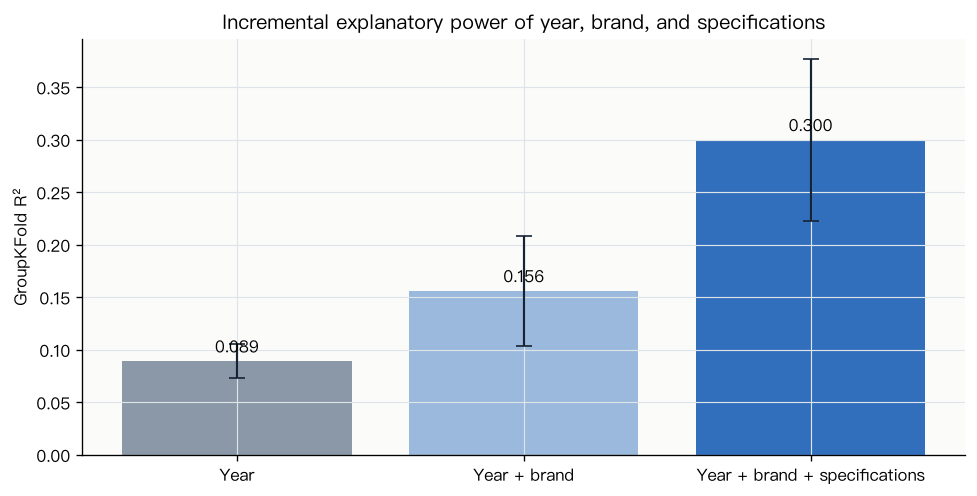

In [8]:
frame = config.copy()
name = "方案" if ZH else "Model"
frame[name] = frame.variant.map({
    "YEAR-ONLY": "年份" if ZH else "Year",
    "+BRAND": "年份 + 品牌" if ZH else "Year + brand",
    "+CONFIG": "年份 + 品牌 + 配置" if ZH else "Year + brand + specifications",
    "CONFIG-ONLY": "仅配置" if ZH else "Specifications only",
})
display(frame[[name, "R2_log_mean", "R2_log_std", "WMAPE_mean", "n_features"]]
        .style.format({"R2_log_mean": "{:.3f}", "R2_log_std": "{:.3f}",
                       "WMAPE_mean": "{:.2f}%"}))
ordered = frame[frame.variant.isin(["YEAR-ONLY", "+BRAND", "+CONFIG"])]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.bar(ordered[name], ordered.R2_log_mean,
              color=[COLORS["gray"], COLORS["light"], COLORS["blue"]])
ax.errorbar(ordered[name], ordered.R2_log_mean, yerr=ordered.R2_log_std,
            fmt="none", ecolor=COLORS["navy"], capsize=5, lw=1.3)
ax.set(title=("年份、品牌与配置的增量解释力" if ZH else
              "Incremental explanatory power of year, brand, and specifications"),
       xlabel="", ylabel="GroupKFold R²")
ax.bar_label(bars, fmt="%.3f", padding=4)
plt.show()


**Interpretation:** R² rises from 0.089 to 0.156 after adding brand and reaches 0.300 after adding specifications. This is an out-of-fold explanatory association across series, not a causal estimate for an individual feature.


## 4. User needs and review risk

The strict corpus contains 24,175 reviews. Mention share and negative share among scored mentions remain separate, so discussion volume is not conflated with dissatisfaction.


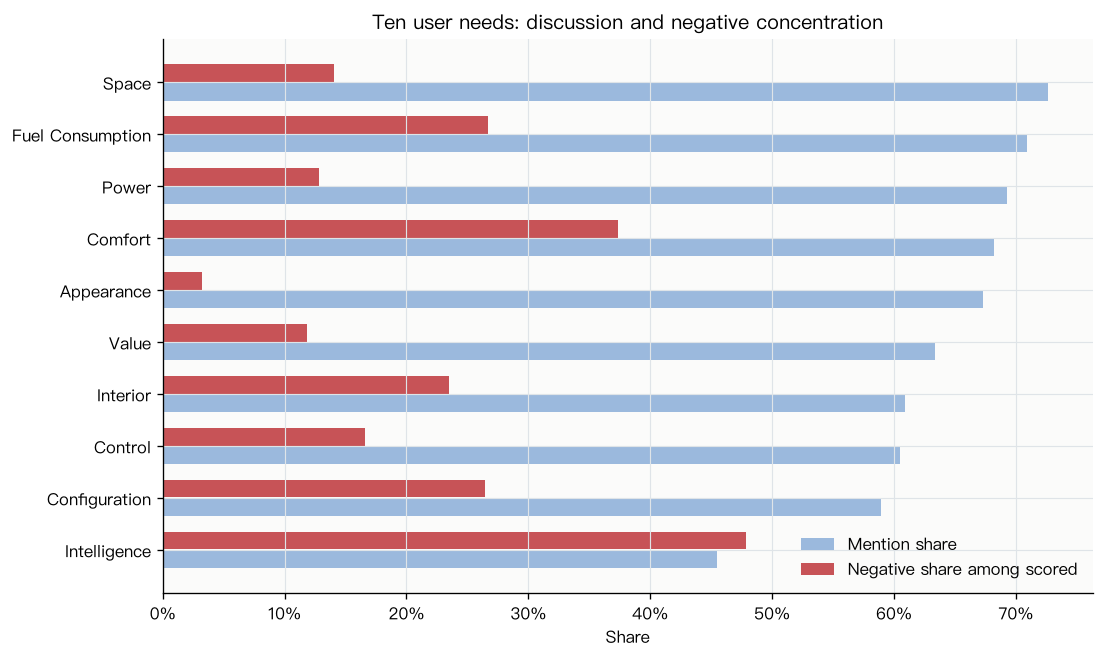

,Dimension,Mention share,Negative share,Mean polarity
9,intelligence,45.5%,47.9%,-0.058
3,comfort,68.2%,37.4%,0.123
1,fuel_consumption,70.9%,26.7%,0.318
8,configuration,58.9%,26.4%,0.375
6,interior,60.9%,23.5%,0.368


In [9]:
ordered = aspects.sort_values("mention_rate")
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(ordered))
ax.barh(y-.18, ordered.mention_rate, height=.34, color=COLORS["light"],
        label=("提及率" if ZH else "Mention share"))
ax.barh(y+.18, ordered.negative_rate_among_scored, height=.34, color=COLORS["red"],
        label=("负面率（有效评分内）" if ZH else "Negative share among scored"))
labels_y = ordered.aspect_zh if ZH else ordered.aspect.str.replace("_", " ").str.title()
ax.set_yticks(y, labels_y)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set(title=("十类用户需求：讨论热度与负面集中度" if ZH else
              "Ten user needs: discussion and negative concentration"),
       xlabel=("比例" if ZH else "Share"), ylabel="")
ax.legend(frameon=False, loc="lower right")
plt.show()

top = aspects.sort_values("negative_rate_among_scored", ascending=False).head(5)
if ZH:
    top = top[["aspect_zh", "mention_rate", "negative_rate_among_scored", "mean_polarity"]]
    top.columns = ["维度", "提及率", "负面率", "平均倾向"]
    display(top.style.format({"提及率": "{:.1%}", "负面率": "{:.1%}", "平均倾向": "{:.3f}"}))
else:
    top = top[["aspect", "mention_rate", "negative_rate_among_scored", "mean_polarity"]]
    top.columns = ["Dimension", "Mention share", "Negative share", "Mean polarity"]
    display(top.style.format({"Mention share": "{:.1%}", "Negative share": "{:.1%}",
                              "Mean polarity": "{:.3f}"}))


### Rule-based alerts

Both adjacent 180-day windows must meet the minimum review count and all score, deterioration, and negative-share thresholds. An alert queues manual review.


In [10]:
latest = alerts.information_cutoff_inclusive.max()
current = alerts[(alerts.information_cutoff_inclusive == latest)
                 & alerts.alert.astype(str).str.lower().isin(["true", "1"])].copy()
if ZH:
    overview = pd.DataFrame([
        ["最近完整监测月", monitor["latest_completed_monitoring_month"]],
        ["达到样本门槛的车系", monitor["latest_eligible_series"]],
        ["当前预警", monitor["latest_active_alerts"]],
        ["历史预警事件", monitor["historical_alert_events"]],
    ], columns=["项目", "数值"])
else:
    overview = pd.DataFrame([
        ["Latest complete month", monitor["latest_completed_monitoring_month"]],
        ["Eligible series", monitor["latest_eligible_series"]],
        ["Current alerts", monitor["latest_active_alerts"]],
        ["Historical alert events", monitor["historical_alert_events"]],
    ], columns=["Item", "Value"])
display(overview)
display(current[["series_name", "brand", "current_reviews", "current_overall_score",
                 "score_change", "current_negative_review_rate", "worst_aspect", "risk_level"]])


,Item,Value
0,Latest complete month,2026-07-31
1,Eligible series,123
2,Current alerts,1
3,Historical alert events,60


,series_name,brand,current_reviews,current_overall_score,score_change,current_negative_review_rate,worst_aspect,risk_level
22,奥迪Q4 e-tron,奥迪,5,-0.233333,-0.15,0.4,appearance,medium


## 5. Data quality and temporal availability


In [11]:
if ZH:
    audit = pd.DataFrame([
        ["严格评论语料", f"{corpus['temporally_eligible_reviews']:,} 条", "完整正文、时间和来源"],
        ["排除的列表摘要", f"{corpus['autohome_list_summary_rows_excluded_from_temporal_model']} 条",
         "无详情正文，不建模"],
        ["测试起点前有评论", f"{temporal['fixed_test_series_with_any_prior_review']} 个车系",
         "冻结于 2026-01-01 前"],
        ["最近 180 天有评论", f"{temporal['fixed_test_series_with_recent_180d_review']} 个车系",
         "其余保留缺失标记"],
        ["复用历史标签", f"{labels['historical_labeled_reviews']:,} 条", "保留来源与标签限制"],
        ["补充标签", f"{labels['api_labeled_reviews']:,} 条", "结构校验与人工抽样"],
    ], columns=["审计项", "结果", "处理"])
else:
    audit = pd.DataFrame([
        ["Strict review corpus", f"{corpus['temporally_eligible_reviews']:,} reviews",
         "Complete text, time, and source"],
        ["Excluded list summaries", corpus["autohome_list_summary_rows_excluded_from_temporal_model"],
         "No full detail text; not modeled"],
        ["Review evidence before test origin", f"{temporal['fixed_test_series_with_any_prior_review']} series",
         "Frozen before 2026-01-01"],
        ["Review in prior 180 days", f"{temporal['fixed_test_series_with_recent_180d_review']} series",
         "Missingness retained elsewhere"],
        ["Reused historical labels", f"{labels['historical_labeled_reviews']:,}",
         "Source and label limitations retained"],
        ["Newly supplemented labels", f"{labels['api_labeled_reviews']:,}",
         "Schema checks and manual sampling"],
    ], columns=["Audit item", "Result", "Treatment"])
display(audit)


,Audit item,Result,Treatment
0,Strict review corpus,"24,175 reviews","Complete text, time, and source"
1,Excluded list summaries,103,No full detail text; not modeled
2,Review evidence before test origin,330 series,Frozen before 2026-01-01
3,Review in prior 180 days,272 series,Missingness retained elsewhere
4,Reused historical labels,"16,538",Source and label limitations retained
5,Newly supplemented labels,"7,637",Schema checks and manual sampling


## 6. Dashboard and reproduction

The dashboard is a static site backed by pre-baked JSON in `app/static/data/`. All six English captures are in `assets/dashboard/en/`.

![Project overview](../assets/dashboard/en/01-overview.png)

Launch from the repository root:

    python -m http.server 8000 --directory app


## 7. Conclusions

1. Sales history remains the dominant forecasting signal; owner feedback adds a modest but not yet robustly significant increment.
2. Product specifications improve the explanation of annual cross-series variation, but the result is associational.
3. Review data is most directly useful for demand structure and risk monitoring; mention, polarity, and sample size should be reported separately.
4. Fixed temporal splits, origin freezing, and full-text quality thresholds make the results auditable.
